# Notebook Explore Analysis

Este notebook tiene como objetivo comprender la estructura, calidad y comportamiento inicial de los datos antes de construir el modelo de forecasting.

El análisis se enfoca en validar la granularidad de la información, revisar consistencia entre tablas, 
identificar valores faltantes y observar patrones generales de demanda que puedan orientar las decisiones de modelado.

## Librerias 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

## Data

In [2]:
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

transactions = pd.read_csv(ROOT / "data" / "raw" / "transactions.csv")
stores = pd.read_csv(ROOT / "data" / "raw" / "stores.csv")
calendar = pd.read_csv(ROOT / "data" / "raw" / "calendar.csv")

## EDA

### Transactions

El dataset de transacciones constituye la principal fuente de información del proyecto, ya que concentra la demanda observada para cada combinación de tienda, categoría y día. Antes de construir un modelo de pronóstico es necesario validar que esta información sea consistente y suficientemente completa, pues cualquier anomalía podría propagarse al resto del proceso analítico.

In [3]:
transactions.head(2)

,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,244732.98,NaN,101822.79,2299.0,NaN,0,NaN
1,2023-01-02,STR_001,Abarrotes,1298,750.0,548,373235.09,222834.25,150400.84,3011.0,287.55,0,NaN


In [4]:
transactions.shape

(203958, 13)

In [5]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203958 entries, 0 to 203957
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   date                  203958 non-null  object 
 1   store_id              203958 non-null  object 
 2   category              203958 non-null  object 
 3   total_transactions    203958 non-null  int64  
 4   cash_transactions     191835 non-null  float64
 5   card_transactions     203958 non-null  int64  
 6   amount_total          203958 non-null  float64
 7   amount_cash           191835 non-null  float64
 8   amount_card           203958 non-null  float64
 9   units_sold            197840 non-null  float64
 10  avg_ticket            199084 non-null  float64
 11  has_promotion         203958 non-null  int64  
 12  replenishment_signal  202998 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 20.2+ MB


In [6]:
null_counts = transactions.isnull().sum()
null_pct = (null_counts / len(transactions) * 100).round(2)

null_summary = pd.DataFrame({
    'Valores nulos': null_counts,
    '% del total': null_pct
}).query('`Valores nulos` > 0').sort_values('% del total', ascending=False)

null_summary

,Valores nulos,% del total
cash_transactions,12123,5.94
amount_cash,12123,5.94
units_sold,6118,3.00
avg_ticket,4874,2.39
replenishment_signal,960,0.47


In [7]:
transactions[transactions['cash_transactions'].isna()].amount_cash.isna().sum()

12123

cash_transactions y amount_cash (~6%): presentan exactamente el mismo patrón de valores faltantes, lo que resulta consistente al tratarse de métricas asociadas a pagos en efectivo y cuyo diccionario de datos indica que pueden contener nulos.


replenishment_signal (~0.5%): corresponde a una variable generada por un proceso interno del negocio. Debido a que se desconoce la lógica con la que fue construida, su tratamiento se evaluará durante la etapa de preparación de datos.


units_sold (~3%) y avg_ticket (~2.4%): presentan un porcentaje moderado de valores faltantes que deberá considerarse en la estrategia de preprocesamiento

In [8]:
transactions['date'] = pd.to_datetime(transactions['date'])

total_days = (transactions['date'].max() - transactions['date'].min()).days + 1
days_per_store = transactions.groupby('store_id')['date'].nunique()

incomplete_stores = days_per_store[days_per_store < total_days].reset_index()
incomplete_stores.columns = ['store_id', 'dias_registrados']
incomplete_stores['dias_faltantes'] = total_days - incomplete_stores['dias_registrados']
incomplete_stores['pct_faltante'] = (incomplete_stores['dias_faltantes'] / total_days * 100).round(2)

print(f"Días esperados por tienda: {total_days}")
print(f"Tiendas con días incompletos: {len(incomplete_stores)} de {transactions['store_id'].nunique()}\n")
incomplete_stores

Días esperados por tienda: 425
Tiendas con días incompletos: 3 de 80



,store_id,dias_registrados,dias_faltantes,pct_faltante
0,STR_045,423,2,0.47
1,STR_055,422,3,0.71
2,STR_064,423,2,0.47


In [9]:
# Verificar si los días faltantes son aislados o periodos consecutivos
for store in incomplete_stores['store_id']:
    store_dates = transactions[transactions['store_id'] == store]['date'].sort_values()
    all_dates = pd.date_range(start=transactions['date'].min(), end=transactions['date'].max())
    missing_dates = all_dates[~all_dates.isin(store_dates)]
    
    # Detectar si los gaps son consecutivos
    gaps = (missing_dates.to_series().diff() > pd.Timedelta('1 day')).sum()
    print(f"{store}: {len(missing_dates)} días faltantes — {'periodos consecutivos' if gaps < len(missing_dates) - 1 else 'días aislados'} ({gaps + 1} bloque(s) de ausencia)")

STR_045: 2 días faltantes — periodos consecutivos (1 bloque(s) de ausencia)
STR_055: 3 días faltantes — periodos consecutivos (1 bloque(s) de ausencia)
STR_064: 2 días faltantes — periodos consecutivos (1 bloque(s) de ausencia)


Solo 3 de las 80 tiendas presentan días faltantes, con menos de 3 días de ausencia cada una — un porcentaje menor al 1% del periodo total. El hecho de que los días faltantes estén concentrados en bloques consecutivos sugiere problemas de conectividad o cierre temporal, y no errores de captura aleatorios.

Dado el volumen reducido, estas tiendas no serán excluidas del análisis. Sin embargo, durante el preprocesamiento será necesario definir si estos días se imputan o se excluyen del conjunto de entrenamiento para no introducir discontinuidades en las series temporales.

In [10]:
transactions.describe().round(2)

,date,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
count,203958,203958.00,191835.00,203958.00,203958.00,191835.00,203958.00,197840.00,199084.00,203958.0,202998.00
mean,2023-08-01 00:03:08.085782272,613.51,273.98,313.10,170581.26,71623.69,98908.20,1175.41,411.76,0.2,614.45
min,2023-01-01 00:00:00,14.00,3.00,11.00,6922.32,2721.28,4201.04,22.00,69.86,0.0,34.67
25%,2023-04-17 00:00:00,228.00,77.00,136.00,78798.17,30519.27,44898.69,418.00,182.44,0.0,249.86
50%,2023-08-01 00:00:00,424.00,169.00,234.00,129965.23,51462.28,74877.42,793.00,297.03,0.0,447.57
75%,2023-11-15 00:00:00,783.00,352.00,399.00,213323.91,86819.46,124418.91,1487.00,534.14,0.0,809.57
max,2024-02-29 00:00:00,15194.00,8387.00,6827.00,4050995.63,2294517.17,2269315.38,31936.00,1931.74,1.0,7064.00
std,NaN,631.77,323.69,286.56,150445.65,71687.13,88072.57,1264.96,303.64,0.4,538.10


In [11]:
transactions.store_id.nunique()

80

In [12]:
transactions.groupby(['category'])[['total_transactions']].sum().sort_values(by='total_transactions', ascending=False)

,total_transactions
category,
Abarrotes,40252500
Bebidas,31274705
Cuidado_Personal,20103737
Hogar,15623305
Ropa,11166847
Electronica,6709887


In [13]:
print(transactions["date"].min(), "to", transactions["date"].max())

2023-01-01 00:00:00 to 2024-02-29 00:00:00


In [14]:
transactions['has_promotion'].value_counts(normalize=True)

has_promotion
0    0.800228
1    0.199772
Name: proportion, dtype: float64

### Stores

In [15]:
stores.head(2)

,store_id,store_format,region,size_sqm,num_checkouts,opening_year,socioeconomic_level,has_pharmacy,has_fuel_station
0,STR_001,Supercenter,Norte,11072,37,2020,B,True,False
1,STR_002,Supercenter,Occidente,13502,22,2020,C+,True,False


In [16]:
stores.shape

(80, 9)

In [17]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   store_id             80 non-null     object
 1   store_format         80 non-null     object
 2   region               80 non-null     object
 3   size_sqm             80 non-null     int64 
 4   num_checkouts        80 non-null     int64 
 5   opening_year         80 non-null     int64 
 6   socioeconomic_level  80 non-null     object
 7   has_pharmacy         80 non-null     bool  
 8   has_fuel_station     80 non-null     bool  
dtypes: bool(2), int64(3), object(4)
memory usage: 4.7+ KB


In [18]:
stores.store_id.nunique()

80

In [19]:
stores.store_format.value_counts()

store_format
Bodega         35
Express        25
Supercenter    20
Name: count, dtype: int64

In [20]:
stores.region.value_counts()

region
Occidente    20
Oriente      18
Norte        17
Sur          13
Centro       12
Name: count, dtype: int64

In [21]:
stores.size_sqm.describe().round(2)

count       80.00
mean      5991.05
std       4018.84
min        737.00
25%       2637.50
50%       5135.00
75%       8047.50
max      14784.00
Name: size_sqm, dtype: float64

In [22]:
stores.socioeconomic_level.value_counts() 

socioeconomic_level
C+     27
C      27
B      21
A/B     5
Name: count, dtype: int64

In [23]:
stores.has_pharmacy.sum()

15

In [24]:
stores.has_fuel_station.sum()

22

### Calendar

In [25]:
calendar.head(2)

,date,day_of_week,day_name,week_of_year,month,year,quarter,season,is_holiday,holiday_name,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa
0,2023-01-01,6,Sunday,52,1,2023,1,Invierno,True,Año Nuevo,False,True,True,False,False
1,2023-01-02,0,Monday,1,1,2023,1,Invierno,False,NaN,False,False,True,False,False


In [26]:
calendar.shape

(425, 15)

In [27]:
print(calendar["date"].min(), "to", calendar["date"].max())

2023-01-01 to 2024-02-29


In [28]:
calendar['date'] = pd.to_datetime(calendar['date'])

event_cols = ['is_holiday', 'is_payday', 'is_weekend', 'is_buen_fin', 'is_navidad_season', 'is_semana_santa']
calendar_year = calendar[calendar['date'].dt.year == 2023]
event_summary = pd.DataFrame({
    'Días en el periodo': [calendar_year[col].sum() for col in event_cols],
    '% del periodo': [(calendar_year[col].sum() / len(calendar_year) * 100).round(1) for col in event_cols],
}, index=event_cols)

event_summary

,Días en el periodo,% del periodo
is_holiday,16,4.4
is_payday,24,6.6
is_weekend,105,28.8
is_buen_fin,4,1.1
is_navidad_season,23,6.3
is_semana_santa,2,0.5


Las variables de calendario representan eventos con frecuencias muy distintas. Mientras que fines de semana y quincenas aparecen repetidamente a lo largo del periodo, eventos como Buen Fin o Semana Santa únicamente cuentan con una ocurrencia. Esta diferencia deberá considerarse al interpretar la importancia que el modelo asigne a estas variables.

---

### Observaciones

- El dataset contiene aproximadamente **204 mil registros**, correspondientes a **80 tiendas**, **6 categorías** y un periodo de **425 días** (enero de 2023 a febrero de 2024).
- La variable objetivo (total_transactions) presenta un **100% de completitud**, por lo que puede utilizarse directamente para el modelado.
- Los valores faltantes se concentran en variables específicas y responden a distintos contextos de negocio, por lo que requerirán estrategias de tratamiento diferenciadas.
- Solo **3 tiendas** presentan días sin información (<1% del periodo), concentrados en bloques consecutivos, lo que sugiere interrupciones operativas más que errores aleatorios.
- Aproximadamente el **20% de los registros** corresponde a días con promociones activas, mientras que el calendario incorpora eventos relevantes del retail mexicano como Buen Fin, Navidad y Semana Santa.

### Implicaciones para el modelo

- La alta completitud de total_transactions permite utilizarla como variable objetivo sin necesidad de imputación.
- Las variables de calendario y promociones representan información disponible antes de realizar la predicción, por lo que constituyen candidatos naturales para el modelo de forecasting.
- Los valores faltantes deberán tratarse de manera diferenciada según el significado de cada variable, evitando aplicar una única estrategia de imputación.
- Los periodos sin información identificados en algunas tiendas serán analizados durante el preprocesamiento para determinar el tratamiento más adecuado.
- Debido a que el periodo observado comprende un único ciclo anual, los efectos asociados a eventos como Buen Fin, Navidad y Semana Santa deberán interpretarse con cautela.

### Riesgos identificados

- Los eventos anuales sólo aparecen una vez.
- Algunas variables contienen valores faltantes.
- Existen pequeños periodos sin información en tres tiendas.

## Análisis

In [29]:
# ==========================================
# Plot Style
# ==========================================

WALMART_BLUE    = '#0071CE'
WALMART_DKBLUE  = '#004C91'
WALMART_YELLOW  = '#FFC220'
WALMART_GREY    = '#9E9E9E'
WALMART_LGREY   = '#F5F5F5'
WALMART_DARK    = '#1A1A2E'

CAT_PALETTE = [WALMART_BLUE, WALMART_YELLOW, WALMART_DKBLUE,
               '#5BA4CF', '#FFD966', WALMART_GREY]

plt.style.use("default")

plt.rcParams.update({

    "figure.figsize": (10, 5),

    "axes.facecolor": "white",
    "figure.facecolor": "white",

    "axes.edgecolor": WALMART_GREY,
    "axes.labelcolor": WALMART_DARK,
    "axes.titleweight": "bold",

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.color": WALMART_DARK,
    "ytick.color": WALMART_DARK,

    "font.size": 11

})

### 1 Evolución temporal de la demanda

Antes de analizar la distribución de la variable objetivo, es importante comprender cómo evoluciona la demanda a lo largo del tiempo.

Al tratarse de un problema de forecasting, la dimensión temporal constituye el principal componente del análisis. Observar la serie agregada permite identificar tendencias, patrones recurrentes y variaciones que posteriormente deberán ser capturadas por el modelo predictivo.

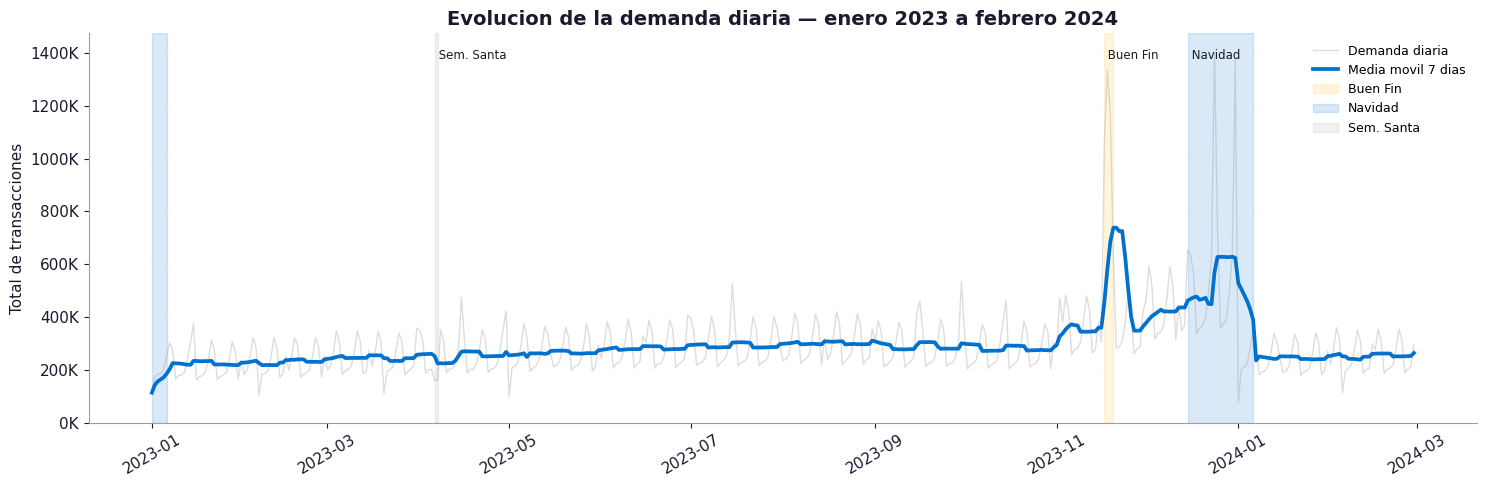

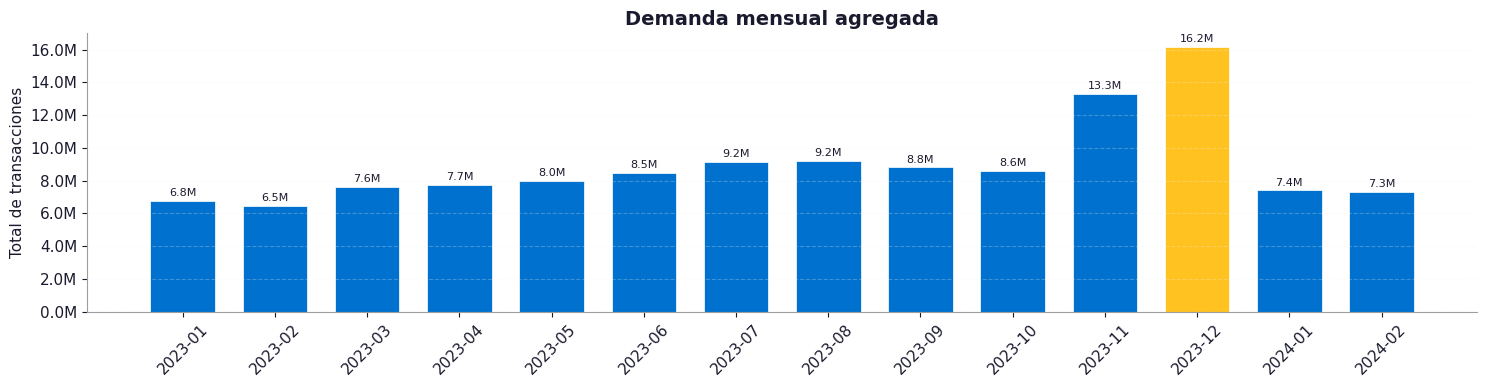

In [34]:
transactions['date'] = pd.to_datetime(transactions['date'])
calendar['date']     = pd.to_datetime(calendar['date'])

daily_demand = (
    transactions
    .groupby('date', as_index=False)
    .agg(total_transactions=('total_transactions', 'sum'))
)
daily_demand['rolling_7'] = (
    daily_demand['total_transactions']
    .rolling(window=7, min_periods=1)
    .mean()
)

def contiguous_spans(dates):
    dates = sorted(pd.to_datetime(dates))
    spans, start, prev = [], dates[0], dates[0]
    for d in dates[1:]:
        if (d - prev).days > 1:
            spans.append((start, prev))
            start = d
        prev = d
    spans.append((start, prev))
    return spans

event_flags = {
    'Buen Fin':   'is_buen_fin',
    'Navidad':    'is_navidad_season',
    'Sem. Santa': 'is_semana_santa',
}
event_colors = {
    'Buen Fin':   WALMART_YELLOW,
    'Navidad':    WALMART_BLUE,
    'Sem. Santa': WALMART_GREY,
}

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_demand['date'], daily_demand['total_transactions'],
        color=WALMART_GREY, alpha=0.35, linewidth=1, label='Demanda diaria')
ax.plot(daily_demand['date'], daily_demand['rolling_7'],
        color=WALMART_BLUE, linewidth=2.7, label='Media movil 7 dias')

ylim_top = daily_demand['total_transactions'].max() * 1.05
labeled  = set()

for name, flag in event_flags.items():
    dates  = calendar.loc[calendar[flag], 'date']
    spans  = contiguous_spans(dates)
    for start, end in spans:
        label = name if name not in labeled else '_nolegend_'
        ax.axvspan(start, end, alpha=0.15, color=event_colors[name], label=label)
        labeled.add(name)
    main = max(spans, key=lambda s: (s[1] - s[0]).days)
    ax.text(main[0], ylim_top * 0.96, f' {name}',
            fontsize=8.5, color=WALMART_DARK, va='top')

ax.set_ylim(0, ylim_top)
ax.set_title('Evolucion de la demanda diaria — enero 2023 a febrero 2024',
             fontsize=14, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Total de transacciones')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

daily_demand['month'] = daily_demand['date'].dt.to_period('M')
monthly = daily_demand.groupby('month')['total_transactions'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)
max_val = monthly['total_transactions'].max()
monthly['color'] = monthly['total_transactions'].apply(
    lambda v: WALMART_YELLOW if v == max_val else WALMART_BLUE
)

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(monthly['month_str'], monthly['total_transactions'],
       color=monthly['color'], edgecolor='white', linewidth=0.5, width=0.7)

ax.set_title('Demanda mensual agregada', fontsize=14, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Total de transacciones')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
ax.tick_params(axis='x', rotation=45)

for i, row in monthly.iterrows():
    ax.text(i, row['total_transactions'] + max_val * 0.01,
            f"{row['total_transactions']/1_000_000:.1f}M",
            ha='center', va='bottom', fontsize=8, color=WALMART_DARK)

plt.tight_layout()
plt.show()

La demanda agregada presenta un comportamiento claramente temporal, con un incremento gradual a lo largo de 2023 y variaciones asociadas a eventos comerciales específicos. La media móvil de 7 días muestra una tendencia creciente durante gran parte del periodo, mientras que la serie diaria evidencia un patrón semanal recurrente, reflejando la influencia del calendario sobre el comportamiento de las transacciones.

Los mayores incrementos se concentran durante Buen Fin y la temporada navideña, aunque ambos eventos muestran comportamientos distintos. Mientras que Buen Fin genera un incremento abrupto y de corta duración, la temporada navideña mantiene niveles elevados de demanda durante varias semanas consecutivas. En contraste, Semana Santa coincide con una disminución temporal en el volumen de transacciones respecto a las semanas adyacentes.

La agregación mensual confirma este comportamiento al mostrar un crecimiento progresivo durante el año y un aumento considerable en los últimos meses de 2023, seguido de una normalización de la demanda una vez concluida la temporada decembrina. En conjunto, estos resultados indican que la demanda está influenciada tanto por patrones temporales recurrentes como por eventos comerciales específicos, lo que justifica incorporar variables de calendario y rezagos temporales dentro del modelo de forecasting para capturar adecuadamente estas variaciones.

## 2. Factores que explican el comportamiento de la demanda

### 2.1 Eventos comerciales y promociones

In [41]:
# Nivel: store-category-day (granularidad original)
# has_promotion tiene variabilidad real a este nivel
cal_cols = ['date', 'is_buen_fin', 'is_navidad_season', 'is_semana_santa', 'is_payday']

df = transactions.merge(calendar[cal_cols], on='date')

EVENTS = {
    'Buen Fin':   'is_buen_fin',
    'Navidad':    'is_navidad_season',
    'Sem. Santa': 'is_semana_santa',
    'Quincena':   'is_payday',
}
event_cols    = list(EVENTS.values())
baseline_mask = ~df[event_cols].any(axis=1) & (df['has_promotion'] == 0)
baseline_mean = df.loc[baseline_mask, 'total_transactions'].mean()


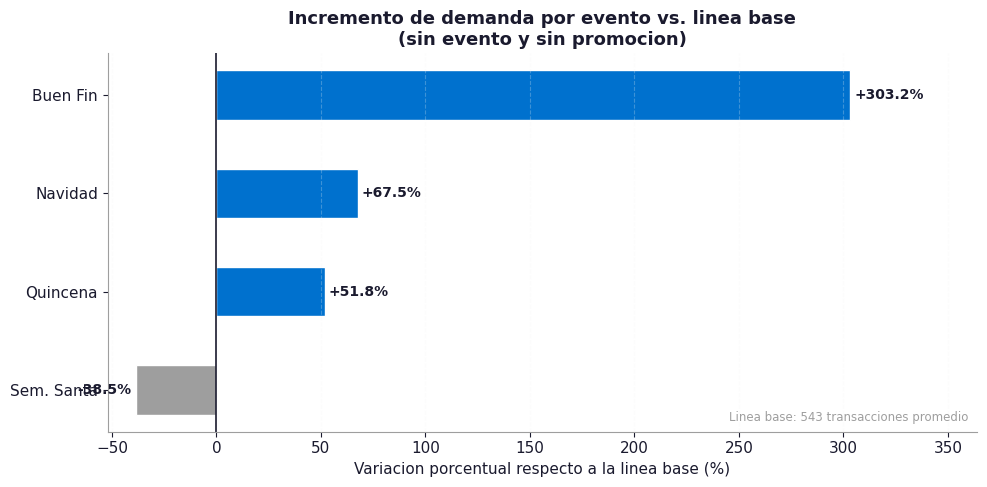

In [42]:
event_means = {
    name: df.loc[df[col], 'total_transactions'].mean()
    for name, col in EVENTS.items()
}
lifts = {
    name: (mean - baseline_mean) / baseline_mean * 100
    for name, mean in event_means.items()
}
lifts_sorted = dict(sorted(lifts.items(), key=lambda x: x[1]))

labels = list(lifts_sorted.keys())
values = list(lifts_sorted.values())
colors = [WALMART_GREY if v < 0 else WALMART_BLUE for v in values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values, color=colors, height=0.5, edgecolor='white')
ax.axvline(0, color=WALMART_DARK, linewidth=1.2)

for bar, val in zip(bars, values):
    sign = '+' if val >= 0 else ''
    xpos = val + (2 if val >= 0 else -2)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{sign}{val:.1f}%', va='center', ha=ha,
            fontsize=10, fontweight='bold', color=WALMART_DARK)

ax.set_title(
    'Incremento de demanda por evento vs. linea base\n(sin evento y sin promocion)',
    fontsize=13, fontweight='bold', color=WALMART_DARK
)
ax.set_xlabel('Variacion porcentual respecto a la linea base (%)')
ax.set_xlim(min(values) * 1.35, max(values) * 1.20)
ax.grid(axis='x', linestyle='--', alpha=0.25, color=WALMART_LGREY)
ax.tick_params(axis='y', labelsize=11)
ax.text(0.99, 0.02, f'Linea base: {baseline_mean:,.0f} transacciones promedio',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5, color=WALMART_GREY)
plt.tight_layout()
plt.show()


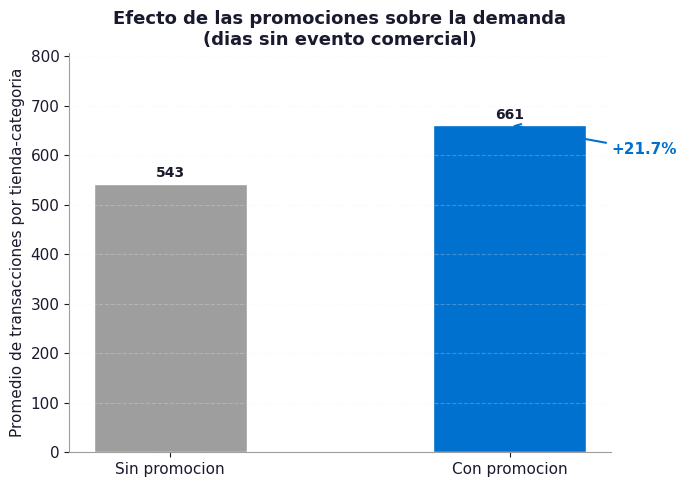

In [43]:
no_event_mask = ~df[event_cols].any(axis=1)

promo_labels = ['Sin promocion', 'Con promocion']
promo_means  = [
    df.loc[no_event_mask & (df['has_promotion'] == 0), 'total_transactions'].mean(),
    df.loc[no_event_mask & (df['has_promotion'] == 1), 'total_transactions'].mean(),
]
promo_lift = (promo_means[1] - promo_means[0]) / promo_means[0] * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(promo_labels, promo_means,
              color=[WALMART_GREY, WALMART_BLUE], width=0.45, edgecolor='white')

for bar, val in zip(bars, promo_means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(promo_means) * 0.01,
            f'{val:,.0f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=WALMART_DARK)

ax.annotate(
    f'+{promo_lift:.1f}%',
    xy=(1, promo_means[1]),
    xytext=(1.3, (promo_means[0] + promo_means[1]) / 2),
    fontsize=11, fontweight='bold', color=WALMART_BLUE,
    arrowprops=dict(arrowstyle='->', color=WALMART_BLUE, lw=1.5),
)
ax.set_title('Efecto de las promociones sobre la demanda\n(dias sin evento comercial)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Promedio de transacciones por tienda-categoria')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, max(promo_means) * 1.22)
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


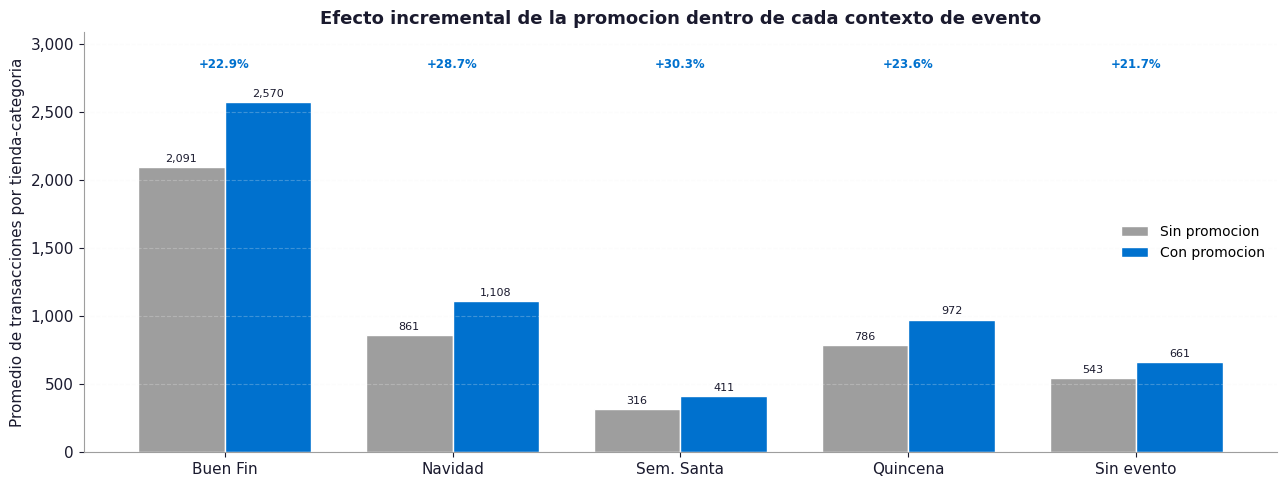

In [44]:
groups = {**EVENTS, 'Sin evento': None}

results = {}
for name, col in groups.items():
    mask = df[col] if col else ~df[event_cols].any(axis=1)
    results[name] = {
        'sin': df.loc[mask & (df['has_promotion'] == 0), 'total_transactions'].mean(),
        'con': df.loc[mask & (df['has_promotion'] == 1), 'total_transactions'].mean(),
    }

group_labels = list(results.keys())
sin_promo    = [results[g]['sin'] for g in group_labels]
con_promo    = [results[g]['con'] for g in group_labels]
x     = np.arange(len(group_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, sin_promo, width, color=WALMART_GREY,
            label='Sin promocion', edgecolor='white')
b2 = ax.bar(x + width/2, con_promo, width, color=WALMART_BLUE,
            label='Con promocion', edgecolor='white')

max_val = max(sin_promo + con_promo)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.01,
                f'{bar.get_height():,.0f}',
                ha='center', va='bottom', fontsize=8, color=WALMART_DARK)

for i, name in enumerate(group_labels):
    s, c  = results[name]['sin'], results[name]['con']
    lift  = (c - s) / s * 100
    sign  = '+' if lift >= 0 else ''
    ax.text(i, max_val * 1.09, f'{sign}{lift:.1f}%',
            ha='center', va='bottom', fontsize=8.5,
            color=WALMART_BLUE, fontweight='bold')

ax.set_title('Efecto incremental de la promocion dentro de cada contexto de evento',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Promedio de transacciones por tienda-categoria')
ax.set_xticks(x)
ax.set_xticklabels(group_labels, fontsize=11)
ax.set_ylim(0, max_val * 1.20)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


El análisis confirma que tanto los eventos comerciales como las promociones tienen un efecto positivo sobre la demanda, aunque su impacto es significativamente diferente. Tomando como referencia un día sin eventos y sin promoción (543 transacciones promedio por tienda-categoría), Buen Fin representa el mayor incremento observado durante el periodo, con una demanda 303.2% superior a la línea base. En contraste, Navidad (+67.5%) y las quincenas (+51.8%) presentan incrementos más moderados, mientras que Semana Santa registra una disminución aproximada del 38.5%, siendo el único evento asociado a una reducción en la actividad comercial.

De manera independiente, las promociones generan un incremento promedio del 21.7% en días sin eventos comerciales (543 vs. 661 transacciones), lo que confirma que constituyen un factor explicativo por sí mismas y no únicamente un efecto asociado al calendario.

Finalmente, al analizar promociones dentro de cada contexto de negocio, se observa un patrón consistente: independientemente del evento, activar una promoción incrementa la demanda entre 21.7% y 30.3% respecto a días equivalentes sin promoción. Esto sugiere que el efecto de las promociones es relativamente estable y complementa el impacto propio de cada evento comercial, justificando la incorporación tanto de variables de calendario como de promociones dentro del modelo de forecasting.

Aunque los eventos comerciales explican gran parte de las variaciones observadas en la demanda, las promociones mantienen un efecto incremental positivo incluso durante estos periodos, lo que indica que ambas variables aportan información complementaria y no deberían considerarse redundantes dentro del modelo.

### 2.2 Categorías


In [ ]:
cat_share = (
    df.groupby('category')['total_transactions']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)
cat_share['pct'] = cat_share['total_transactions'] / cat_share['total_transactions'].sum() * 100

daily_cat = (
    df.groupby(['date', 'category'])['total_transactions']
    .sum()
    .reset_index()
)
cv_cat = (
    daily_cat.groupby('category')['total_transactions']
    .agg(['mean', 'std'])
    .assign(cv=lambda x: x['std'] / x['mean'])
    .sort_values('cv', ascending=True)
    .reset_index()
)

no_event_mask = ~df[event_cols].any(axis=1)
promo_lift_cat = {}
for cat in df['category'].unique():
    mask_cat = no_event_mask & (df['category'] == cat)
    base  = df.loc[mask_cat & (df['has_promotion'] == 0), 'total_transactions'].mean()
    promo = df.loc[mask_cat & (df['has_promotion'] == 1), 'total_transactions'].mean()
    promo_lift_cat[cat] = (promo - base) / base * 100
promo_lift_cat = pd.Series(promo_lift_cat).sort_values(ascending=True)

event_cat_lifts = {}
for cat in df['category'].unique():
    base_mask = ~df[event_cols].any(axis=1) & (df['has_promotion'] == 0) & (df['category'] == cat)
    base_cat  = df.loc[base_mask, 'total_transactions'].mean()
    event_cat_lifts[cat] = {
        evt: (df.loc[df[col] & (df['category'] == cat), 'total_transactions'].mean() - base_cat) / base_cat * 100
        for evt, col in EVENTS.items()
    }
heatmap_df = pd.DataFrame(event_cat_lifts).T


In [49]:
heatmap_df.round(2)

,Buen Fin,Navidad,Sem. Santa,Quincena
Abarrotes,304.59,67.07,-37.32,51.33
Bebidas,304.87,69.32,-39.05,52.21
Cuidado_Personal,301.81,67.21,-39.23,52.24
Electronica,301.92,68.90,-38.87,51.73
Hogar,300.99,66.91,-40.04,52.32
Ropa,301.63,65.45,-37.52,50.95


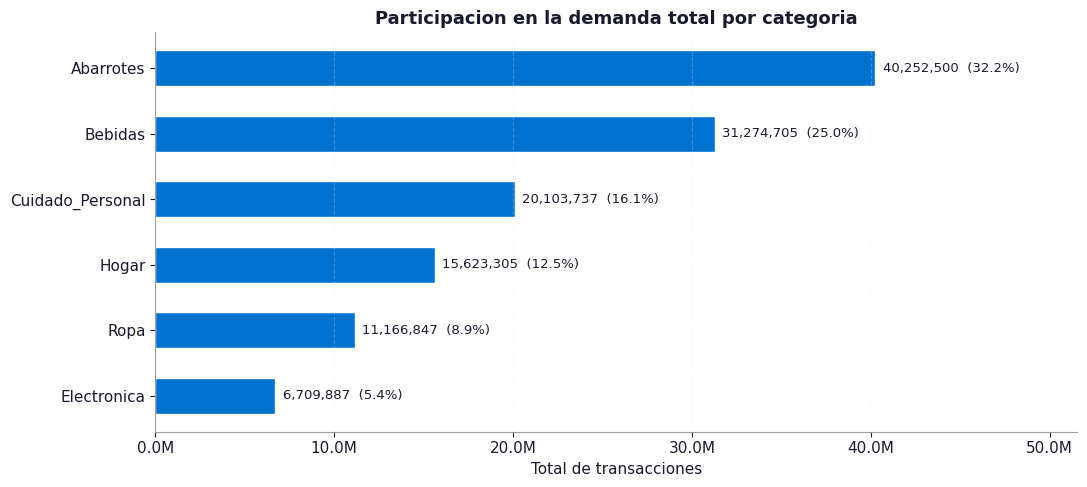

In [47]:
fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(
    cat_share['category'], cat_share['total_transactions'],
    color=WALMART_BLUE, height=0.55, edgecolor='white'
)

max_val = cat_share['total_transactions'].max()
for bar, row in zip(bars, cat_share.itertuples()):
    ax.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{row.total_transactions:,.0f}  ({row.pct:.1f}%)',
        va='center', ha='left', fontsize=9.5, color=WALMART_DARK
    )

ax.set_title('Participacion en la demanda total por categoria',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Total de transacciones')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlim(0, max_val * 1.28)
ax.grid(axis='x', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


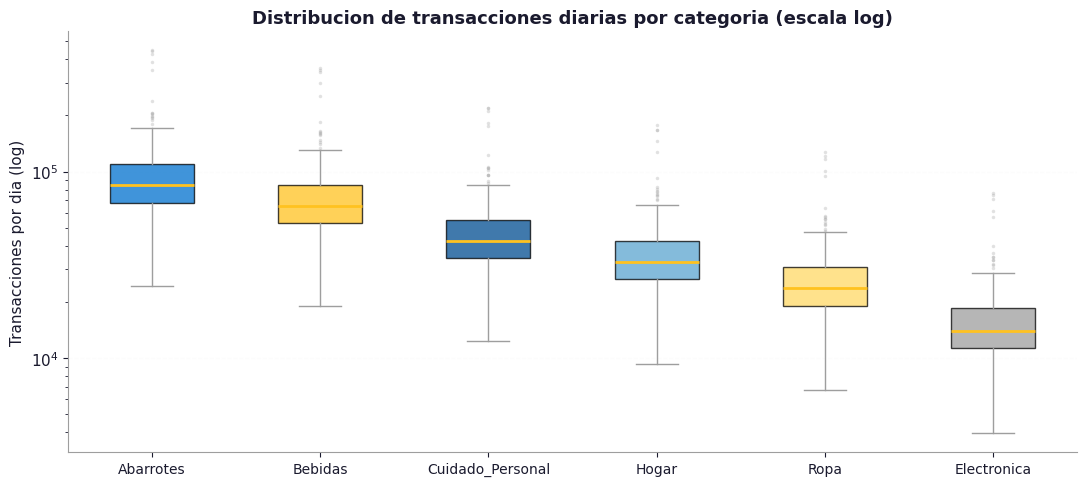

In [50]:
cat_order = (
    daily_cat.groupby('category')['total_transactions']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data_by_cat = [daily_cat.loc[daily_cat['category'] == c, 'total_transactions'].values
               for c in cat_order]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(
    data_by_cat,
    vert=True,
    patch_artist=True,
    medianprops=dict(color=WALMART_YELLOW, linewidth=2),
    whiskerprops=dict(color=WALMART_GREY),
    capprops=dict(color=WALMART_GREY),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3,
                    markerfacecolor=WALMART_GREY, markeredgecolor='none'),
)
for patch, color in zip(bp['boxes'], CAT_PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale('log')
ax.set_xticks(range(1, len(cat_order) + 1))
ax.set_xticklabels(cat_order, fontsize=10)
ax.set_title('Distribucion de transacciones diarias por categoria (escala log)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Transacciones por dia (log)')
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


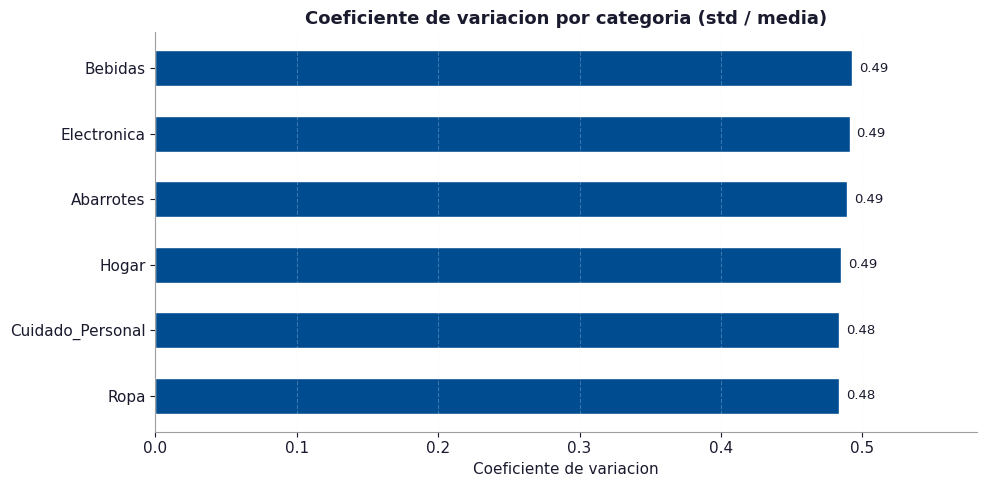

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    cv_cat['category'], cv_cat['cv'],
    color=WALMART_DKBLUE, height=0.55, edgecolor='white'
)

for bar, row in zip(bars, cv_cat.itertuples()):
    ax.text(
        bar.get_width() + cv_cat['cv'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{row.cv:.2f}',
        va='center', ha='left', fontsize=9.5, color=WALMART_DARK
    )

ax.set_title('Coeficiente de variacion por categoria (std / media)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Coeficiente de variacion')
ax.set_xlim(0, cv_cat['cv'].max() * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


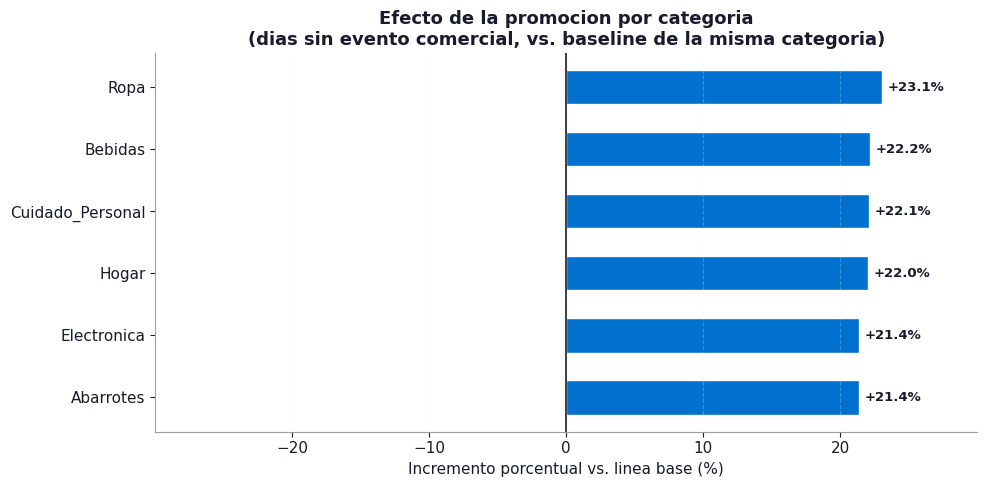

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [WALMART_BLUE if v >= 0 else WALMART_GREY for v in promo_lift_cat.values]
bars   = ax.barh(
    promo_lift_cat.index, promo_lift_cat.values,
    color=colors, height=0.55, edgecolor='white'
)
ax.axvline(0, color=WALMART_DARK, linewidth=1.2)

for bar, val in zip(bars, promo_lift_cat.values):
    sign = '+' if val >= 0 else ''
    xpos = val + (0.4 if val >= 0 else -0.4)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{sign}{val:.1f}%', va='center', ha=ha,
            fontsize=9.5, fontweight='bold', color=WALMART_DARK)

ax.set_title('Efecto de la promocion por categoria\n(dias sin evento comercial, vs. baseline de la misma categoria)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Incremento porcentual vs. linea base (%)')
rng = promo_lift_cat.abs().max()
ax.set_xlim(-rng * 1.3, rng * 1.3)
ax.grid(axis='x', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


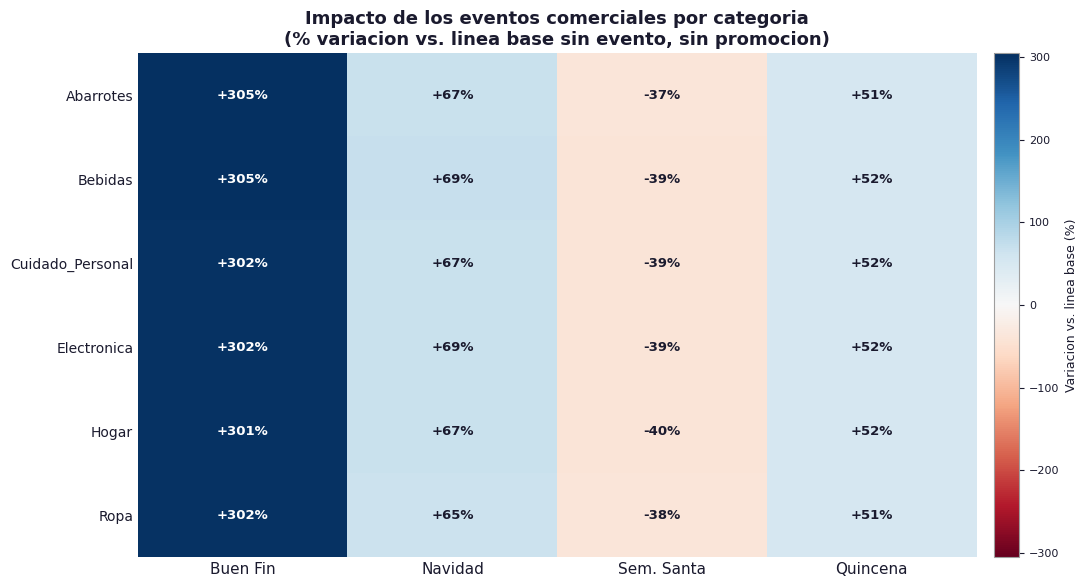

In [ ]:
data   = heatmap_df.values
rows   = heatmap_df.index.tolist()
cols   = heatmap_df.columns.tolist()

vmax  = np.abs(data).max()
norm  = plt.Normalize(vmin=-vmax, vmax=vmax)
cmap  = plt.cm.RdBu

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, fontsize=11)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows, fontsize=10)

for i in range(len(rows)):
    for j in range(len(cols)):
        val   = data[i, j]
        sign  = '+' if val >= 0 else ''
        lum   = 0.299 * cmap(norm(val))[0] + 0.587 * cmap(norm(val))[1] + 0.114 * cmap(norm(val))[2]
        color = 'white' if lum < 0.55 else WALMART_DARK
        ax.text(j, i, f'{sign}{val:.0f}%', ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Variacion vs. linea base (%)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title('Impacto de los eventos comerciales por categoria\n(% variacion vs. linea base sin evento, sin promocion)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

# A diferencia de lo esperado, los principales eventos comerciales muestran un impacto porcentual muy similar entre categorías. 
# Esto sugiere que el incremento observado durante estos periodos responde a un efecto general sobre la operación y no únicamente al comportamiento de categorías específicas.
# ---- pensar

Las categorías presentan diferencias importantes en volumen de demanda, donde Abarrotes (32.2%) y Bebidas (25.0%) concentran más de la mitad de las transacciones del periodo. Sin embargo, su comportamiento relativo resulta sorprendentemente consistente: el coeficiente de variación se mantiene prácticamente igual entre categorías (CV ≈ 0.48–0.49), las promociones generan incrementos muy similares (21.4%–23.1%) y los principales eventos comerciales producen efectos comparables. Estos resultados sugieren que la principal diferencia entre categorías radica en su nivel base de demanda, más que en una respuesta distinta a los factores comerciales, por lo que category deberá incorporarse como una variable estructural del modelo para capturar diferencias de escala entre series.

Aunque el efecto relativo de promociones y eventos es consistente entre categorías, el nivel base de demanda difiere considerablemente. Esto indica que el modelo deberá aprender un comportamiento común frente a los eventos comerciales, pero ajustado al nivel de demanda propio de cada categoría

### 2.3 Características de las tiendas


In [54]:
# Demanda diaria total por tienda (suma de categorias por dia)
store_demand = (
    transactions
    .groupby(['store_id', 'date'])['total_transactions']
    .sum()
    .groupby('store_id')
    .mean()
    .reset_index()
    .rename(columns={'total_transactions': 'daily_mean'})
    .merge(stores, on='store_id')
)

# Distribucion por formato: lista de series para boxplot
fmt_order  = store_demand.groupby('store_format')['daily_mean'].median().sort_values(ascending=False).index.tolist()
fmt_data   = [store_demand.loc[store_demand['store_format'] == f, 'daily_mean'].values for f in fmt_order]

# Farmacia y gasolinera: media de demanda diaria por tienda segun amenidad
amenity_means = {}
for col, label in [('has_pharmacy', 'Farmacia'), ('has_fuel_station', 'Gasolinera')]:
    amenity_means[label] = {
        'sin': store_demand.loc[~store_demand[col], 'daily_mean'].mean(),
        'con': store_demand.loc[ store_demand[col], 'daily_mean'].mean(),
    }

# NSE: media de demanda diaria por nivel
nse_order = (
    store_demand.groupby('socioeconomic_level')['daily_mean']
    .mean()
    .sort_values(ascending=True)
)


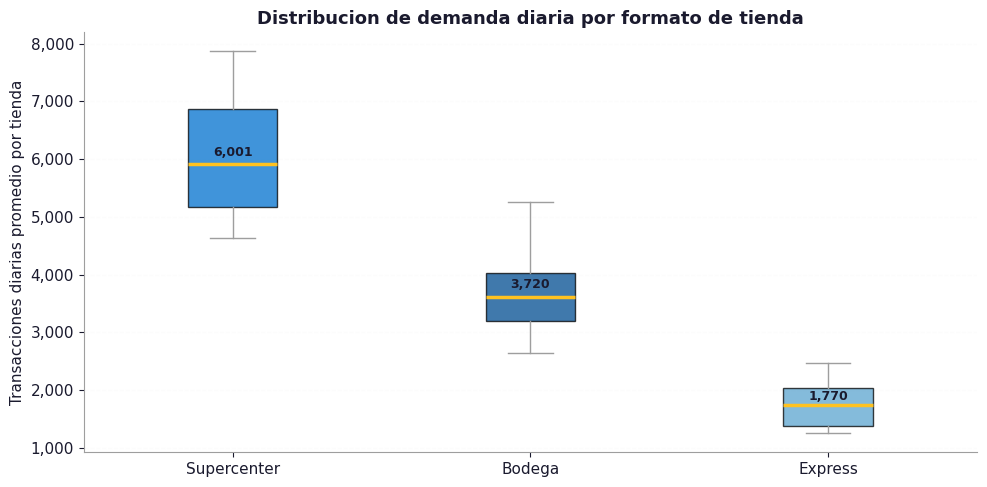

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    fmt_data,
    vert=True,
    patch_artist=True,
    medianprops=dict(color=WALMART_YELLOW, linewidth=2.5),
    whiskerprops=dict(color=WALMART_GREY),
    capprops=dict(color=WALMART_GREY),
    flierprops=dict(marker='o', markersize=4, alpha=0.4,
                    markerfacecolor=WALMART_GREY, markeredgecolor='none'),
)
fmt_colors = [WALMART_BLUE, WALMART_DKBLUE, '#5BA4CF']
for patch, color in zip(bp['boxes'], fmt_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Anotar media sobre cada caja
for i, series in enumerate(fmt_data, start=1):
    mean_val = series.mean()
    ax.text(i, mean_val, f'{mean_val:,.0f}',
            ha='center', va='bottom', fontsize=9,
            color=WALMART_DARK, fontweight='bold')

ax.set_xticks(range(1, len(fmt_order) + 1))
ax.set_xticklabels(fmt_order, fontsize=11)
ax.set_title('Distribucion de demanda diaria por formato de tienda',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Transacciones diarias promedio por tienda')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


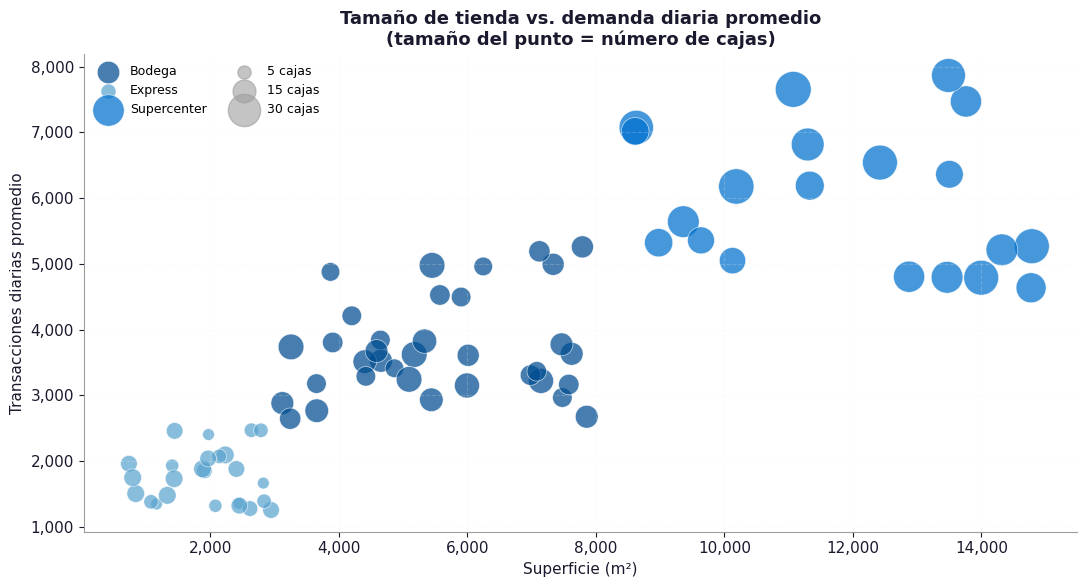

In [56]:
fmt_palette = {'Supercenter': WALMART_BLUE, 'Bodega': WALMART_DKBLUE, 'Express': '#5BA4CF'}

fig, ax = plt.subplots(figsize=(11, 6))

for fmt, grp in store_demand.groupby('store_format'):
    sc = ax.scatter(
        grp['size_sqm'], grp['daily_mean'],
        s=grp['num_checkouts'] * 18,
        color=fmt_palette[fmt], alpha=0.72,
        edgecolors='white', linewidths=0.5,
        label=fmt
    )

# Leyenda de tamaño de punto
for n_chk in [5, 15, 30]:
    ax.scatter([], [], s=n_chk * 18, color=WALMART_GREY, alpha=0.6,
               label=f'{n_chk} cajas')

ax.set_title('Tamaño de tienda vs. demanda diaria promedio\n(tamaño del punto = número de cajas)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Superficie (m²)')
ax.set_ylabel('Transacciones diarias promedio')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(frameon=False, fontsize=9, ncol=2)
ax.grid(linestyle='--', alpha=0.2, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


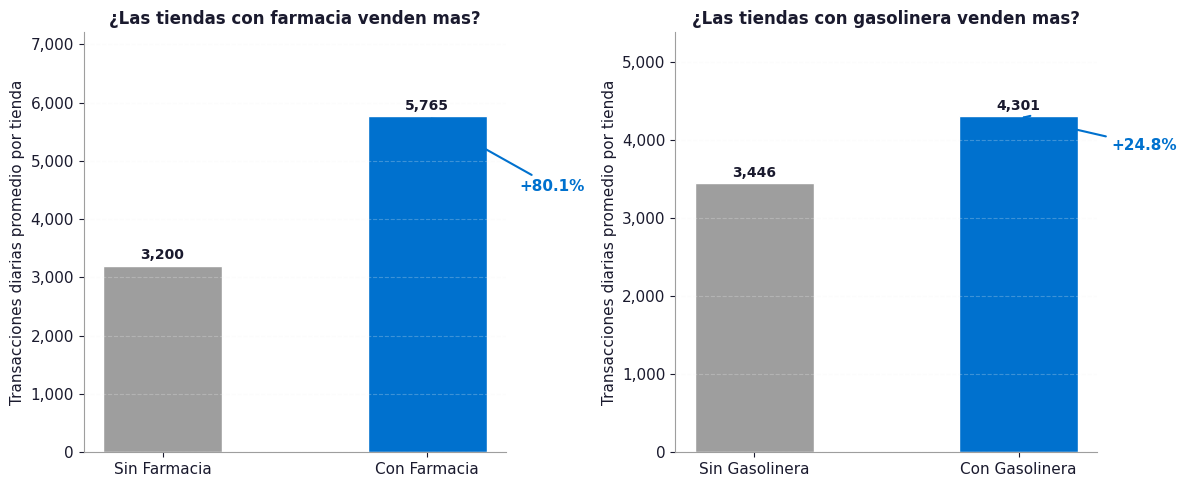

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (label, means) in zip(axes, amenity_means.items()):
    bar_labels = ['Sin ' + label, 'Con ' + label]
    values     = [means['sin'], means['con']]
    colors     = [WALMART_GREY, WALMART_BLUE]
    bars       = ax.bar(bar_labels, values, color=colors, width=0.45, edgecolor='white')

    max_v = max(values)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_v * 0.01,
                f'{val:,.0f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=WALMART_DARK)

    lift = (means['con'] - means['sin']) / means['sin'] * 100
    sign = '+' if lift >= 0 else ''
    ax.annotate(
        f'{sign}{lift:.1f}%',
        xy=(1, means['con']),
        xytext=(1.35, (means['sin'] + means['con']) / 2),
        fontsize=11, fontweight='bold', color=WALMART_BLUE,
        arrowprops=dict(arrowstyle='->', color=WALMART_BLUE, lw=1.5),
    )
    ax.set_title(f'¿Las tiendas con {label.lower()} venden mas?',
                 fontsize=12, fontweight='bold', color=WALMART_DARK)
    ax.set_ylabel('Transacciones diarias promedio por tienda')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylim(0, max_v * 1.25)
    ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)

plt.tight_layout()
plt.show()

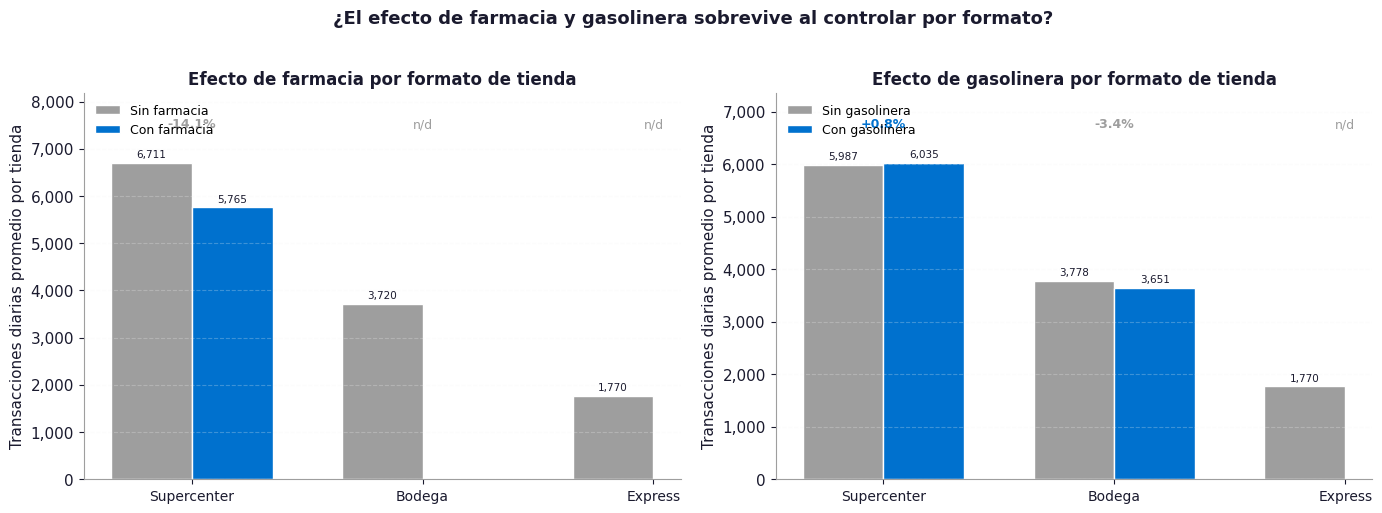

In [ ]:
amenity_fmt = {}
for col, label in [('has_pharmacy', 'Farmacia'), ('has_fuel_station', 'Gasolinera')]:
    amenity_fmt[label] = {}
    for fmt in fmt_order:
        grp = store_demand[store_demand['store_format'] == fmt]
        sin = grp.loc[~grp[col], 'daily_mean'].mean()
        con = grp.loc[ grp[col], 'daily_mean'].mean()
        amenity_fmt[label][fmt] = {'sin': sin, 'con': con}

x     = np.arange(len(fmt_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (label, fmt_data) in zip(axes, amenity_fmt.items()):
    sin_vals = [fmt_data[f]['sin'] for f in fmt_order]
    con_vals = [fmt_data[f]['con'] for f in fmt_order]

    b1 = ax.bar(x - width / 2, sin_vals, width, color=WALMART_GREY,
                label=f'Sin {label.lower()}', edgecolor='white')
    b2 = ax.bar(x + width / 2, con_vals, width, color=WALMART_BLUE,
                label=f'Con {label.lower()}', edgecolor='white')

    max_v = max(sin_vals + con_vals)
    for bar, val in zip(list(b1) + list(b2), sin_vals + con_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max_v * 0.01,
                    f'{val:,.0f}', ha='center', va='bottom',
                    fontsize=7.5, color=WALMART_DARK)

    for i, fmt in enumerate(fmt_order):
        s, c = fmt_data[fmt]['sin'], fmt_data[fmt]['con']
        if not (np.isnan(s) or np.isnan(c)):
            lift = (c - s) / s * 100
            sign = '+' if lift >= 0 else ''
            color = WALMART_BLUE if lift >= 0 else WALMART_GREY
            ax.text(i, max_v * 1.10, f'{sign}{lift:.1f}%',
                    ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color=color)
        else:
            ax.text(i, max_v * 1.10, 'n/d',
                    ha='center', va='bottom', fontsize=9, color=WALMART_GREY)

    ax.set_title(f'Efecto de {label.lower()} por formato de tienda',
                 fontsize=12, fontweight='bold', color=WALMART_DARK)
    ax.set_xticks(x)
    ax.set_xticklabels(fmt_order, fontsize=10)
    ax.set_ylabel('Transacciones diarias promedio por tienda')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_ylim(0, max_v * 1.22)
    ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
    ax.legend(frameon=False, fontsize=9)

plt.suptitle('¿El efecto de farmacia y gasolinera sobrevive al controlar por formato?',
             fontsize=13, fontweight='bold', color=WALMART_DARK, y=1.02)
plt.tight_layout()
plt.show()

A nivel agregado, las tiendas con farmacia (+80.1%) y gasolinera (+24.8%) parecían registrar una demanda considerablemente mayor. Sin embargo, al analizar cada formato de tienda por separado, estas diferencias desaparecen prácticamente por completo: en los Supercenters, las tiendas con farmacia incluso presentan una demanda 14.1% menor, mientras que la presencia de gasolinera modifica la demanda en menos del 1%. Esto indica que el mayor volumen de transacciones no está asociado a la farmacia o la gasolinera en sí, sino a las características estructurales de las tiendas donde suelen estar presentes

Las diferencias en la demanda entre tiendas están explicadas principalmente por sus características estructurales —especialmente el formato y el tamaño—, mientras que variables como farmacia o gasolinera no muestran un efecto independiente una vez considerado ese contexto.

### 2.4 Ubicación geográfica


In [61]:
# Demanda diaria promedio por tienda, enriquecida con región y formato
# store_demand ya existe de sec23_prep

# Q1: demanda promedio por región
region_demand = (
    store_demand.groupby('region')['daily_mean']
    .mean()
    .sort_values(ascending=True)
)

# Q2: composición de formatos por región
region_fmt_counts = (
    stores.groupby(['region', 'store_format'])
    .size()
    .unstack(fill_value=0)
)
region_fmt_pct = region_fmt_counts.div(region_fmt_counts.sum(axis=1), axis=0) * 100
region_fmt_pct = region_fmt_pct.loc[region_demand.index]  # mismo orden que ch1

# Q3: heatmap demanda promedio por región × formato
heatmap_reg_fmt = (
    store_demand.groupby(['region', 'store_format'])['daily_mean']
    .mean()
    .unstack()
)
heatmap_reg_fmt = heatmap_reg_fmt.loc[region_demand.index]

# Q4: serie mensual por región (normalizada por número de tiendas)
n_stores_region = stores.groupby('region')['store_id'].nunique()

transactions['month_dt'] = pd.to_datetime(transactions['date']).dt.to_period('M').dt.to_timestamp()
region_monthly = (
    transactions
    .merge(stores[['store_id', 'region']], on='store_id')
    .groupby(['month_dt', 'region'])['total_transactions']
    .sum()
    .reset_index()
)
region_monthly['txn_per_store'] = (
    region_monthly['total_transactions']
    / region_monthly['region'].map(n_stores_region)
)


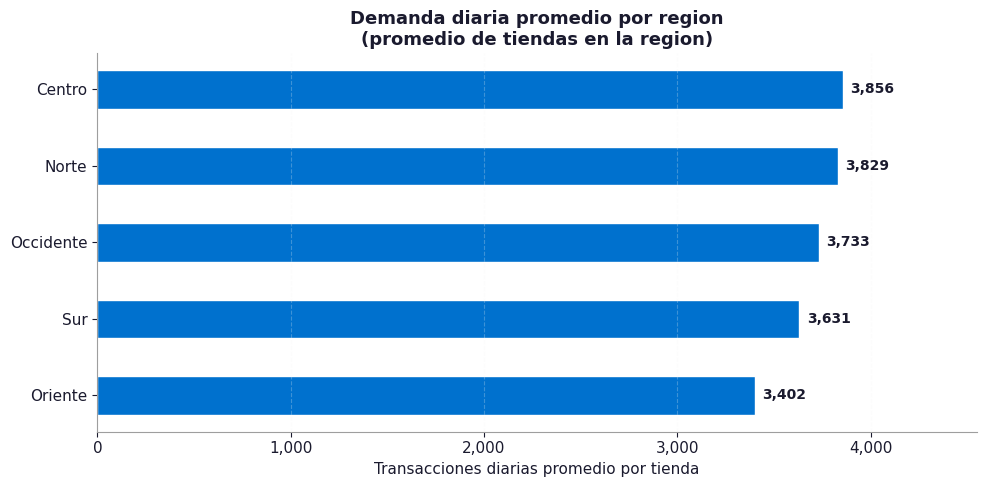

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    region_demand.index, region_demand.values,
    color=WALMART_BLUE, height=0.5, edgecolor='white'
)

max_v = region_demand.max()
for bar, val in zip(bars, region_demand.values):
    ax.text(
        bar.get_width() + max_v * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,.0f}',
        va='center', ha='left', fontsize=10,
        fontweight='bold', color=WALMART_DARK
    )

ax.set_title('Demanda diaria promedio por region\n(promedio de tiendas en la region)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Transacciones diarias promedio por tienda')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, max_v * 1.18)
ax.grid(axis='x', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


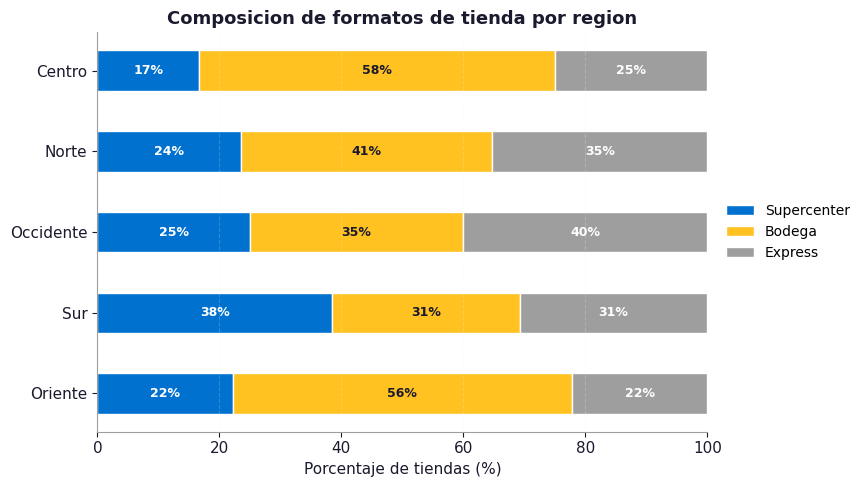

In [68]:
fmt_colors_map = {'Supercenter': WALMART_BLUE, 'Bodega': WALMART_YELLOW, 'Express': WALMART_GREY}
fmt_cols = [c for c in ['Supercenter', 'Bodega', 'Express'] if c in region_fmt_pct.columns]

fig, ax = plt.subplots(figsize=(10, 5))

lefts = np.zeros(len(region_fmt_pct))
for fmt in fmt_cols:
    vals = region_fmt_pct[fmt].values
    bars = ax.barh(
        region_fmt_pct.index, vals,
        left=lefts, color=fmt_colors_map[fmt],
        height=0.5, edgecolor='white', label=fmt
    )
    for bar, val, left in zip(bars, vals, lefts):
        if val > 8:
            lum = 0.299 + 0.587 + 0.114  # placeholder; use fixed contrast per color
            txt_color = WALMART_DARK if fmt == 'Bodega' else 'white'
            ax.text(
                left + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%',
                va='center', ha='center', fontsize=9,
                color=txt_color, fontweight='bold'
            )
    lefts += vals

ax.set_title('Composicion de formatos de tienda por region',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('Porcentaje de tiendas (%)')
ax.set_xlim(0, 100)
ax.legend(frameon=False, fontsize=10, loc='center left',
          bbox_to_anchor=(1.01, 0.5))
ax.grid(axis='x', linestyle='--', alpha=0.2, color=WALMART_LGREY)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


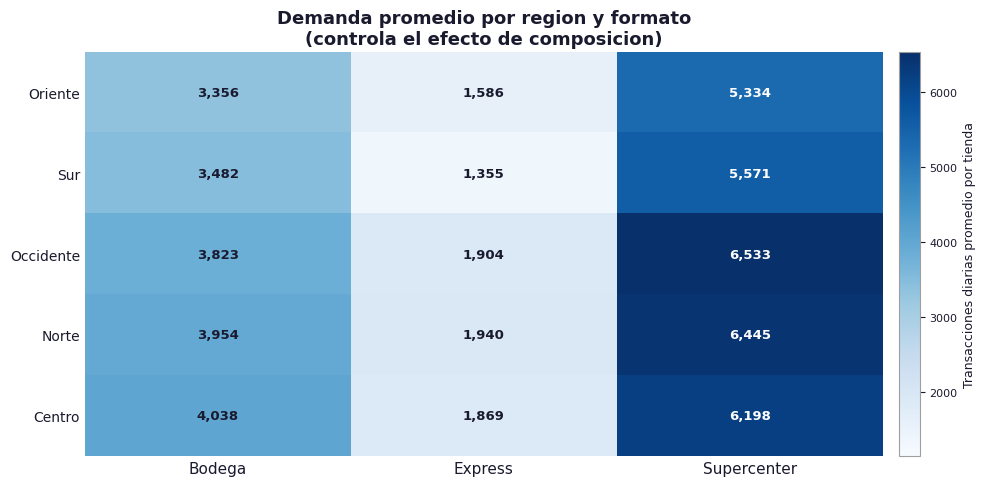

In [64]:
data_h  = heatmap_reg_fmt.values
rows_h  = heatmap_reg_fmt.index.tolist()
cols_h  = heatmap_reg_fmt.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(data_h, cmap='Blues', aspect='auto',
               vmin=np.nanmin(data_h) * 0.85, vmax=np.nanmax(data_h))

ax.set_xticks(range(len(cols_h)))
ax.set_xticklabels(cols_h, fontsize=11)
ax.set_yticks(range(len(rows_h)))
ax.set_yticklabels(rows_h, fontsize=10)

for i in range(len(rows_h)):
    for j in range(len(cols_h)):
        val = data_h[i, j]
        if not np.isnan(val):
            norm_val = (val - np.nanmin(data_h)) / (np.nanmax(data_h) - np.nanmin(data_h))
            txt_color = 'white' if norm_val > 0.55 else WALMART_DARK
            ax.text(j, i, f'{val:,.0f}', ha='center', va='center',
                    fontsize=9.5, fontweight='bold', color=txt_color)
        else:
            ax.text(j, i, 'n/d', ha='center', va='center',
                    fontsize=9, color=WALMART_GREY)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Transacciones diarias promedio por tienda', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title('Demanda promedio por region y formato\n(controla el efecto de composicion)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()


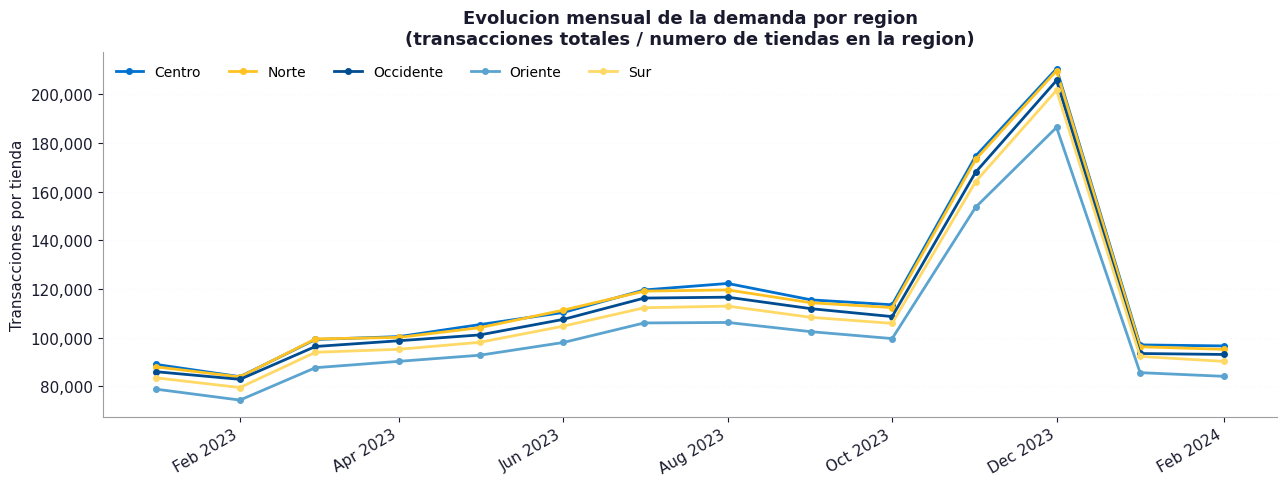

In [67]:
import matplotlib.dates as mdates

regions    = region_monthly['region'].unique()
reg_palette = dict(zip(regions, CAT_PALETTE[:len(regions)]))

fig, ax = plt.subplots(figsize=(13, 5))

for region, grp in region_monthly.groupby('region'):
    grp = grp.sort_values('month_dt')
    ax.plot(
        grp['month_dt'], grp['txn_per_store'],
        color=reg_palette[region], linewidth=2,
        marker='o', markersize=4, label=region
    )

ax.set_title('Evolucion mensual de la demanda por region\n(transacciones totales / numero de tiendas en la region)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_xlabel('')
ax.set_ylabel('Transacciones por tienda')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha='right')
ax.legend(frameon=False, fontsize=10, ncol=len(regions))
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


Aunque inicialmente las regiones muestran diferencias en el nivel promedio de demanda, gran parte de esta variación se explica por la distinta composición de formatos de tienda presente en cada una. Al comparar establecimientos del mismo formato, las diferencias regionales se reducen considerablemente y, además, todas las regiones presentan un patrón temporal muy similar a lo largo del periodo analizado, incluyendo los incrementos durante Buen Fin y Navidad y la disminución posterior en enero. Esto sugiere que la ubicación geográfica influye principalmente sobre el nivel base de demanda, mientras que la dinámica temporal del negocio es consistente en todo el país.

### 2.5 Señal de reposición


In [73]:
import matplotlib.dates as mdates

rep = transactions[['date', 'store_id', 'category',
                     'total_transactions', 'replenishment_signal']].copy()
rep['date'] = pd.to_datetime(rep['date'])

rep_clean = rep.dropna(subset=['replenishment_signal'])

# Serie diaria: mediana de la señal y flag de nulos
daily_rep = (
    rep.groupby('date')
    .agg(
        signal_median=('replenishment_signal', 'median'),
        null_pct=('replenishment_signal', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)
null_days = daily_rep.loc[daily_rep['null_pct'] > 0, 'date']

# Nulos por semana
rep['week'] = rep['date'].dt.to_period('W').dt.start_time
nulls_by_week = (
    rep.groupby('week')['replenishment_signal']
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
)
nulls_by_week.columns = ['week', 'null_pct']


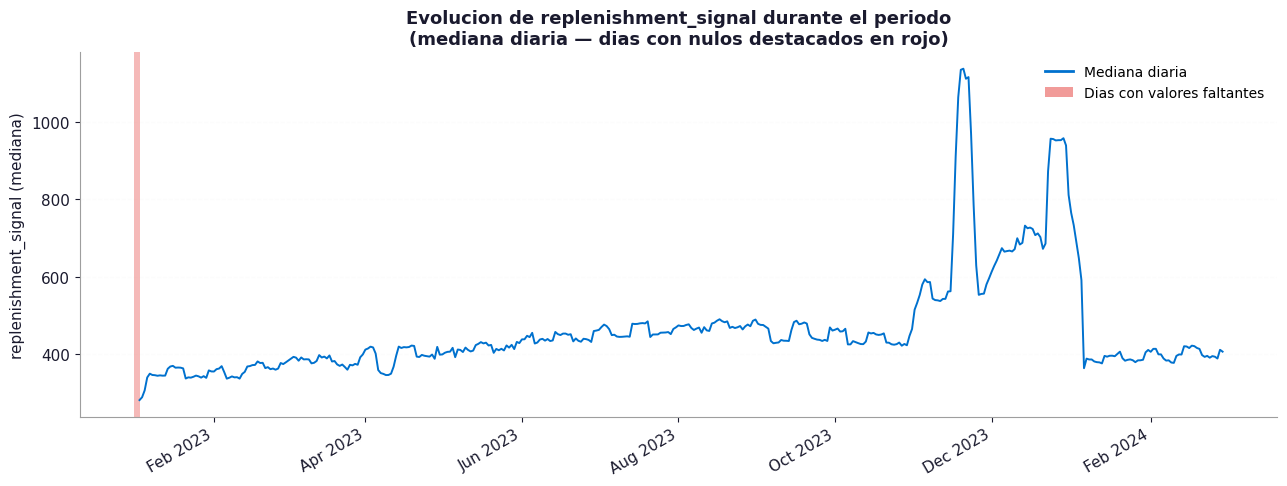

In [75]:
fig, ax = plt.subplots(figsize=(13, 5))

# Serie de la señal
ax.plot(
    daily_rep['date'], daily_rep['signal_median'],
    color=WALMART_BLUE, linewidth=1.4, zorder=3
)

# Días con nulos: franjas verticales en rojo
for d in null_days:
    ax.axvspan(d, d + pd.Timedelta(days=1),
               color='#E53935', alpha=0.35, zorder=2, linewidth=0)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    plt.Line2D([0], [0], color=WALMART_BLUE, linewidth=2, label='Mediana diaria'),
    Patch(facecolor='#E53935', alpha=0.5, label='Dias con valores faltantes'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=10)

ax.set_title('Evolucion de replenishment_signal durante el periodo\n(mediana diaria — dias con nulos destacados en rojo)',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('replenishment_signal (mediana)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


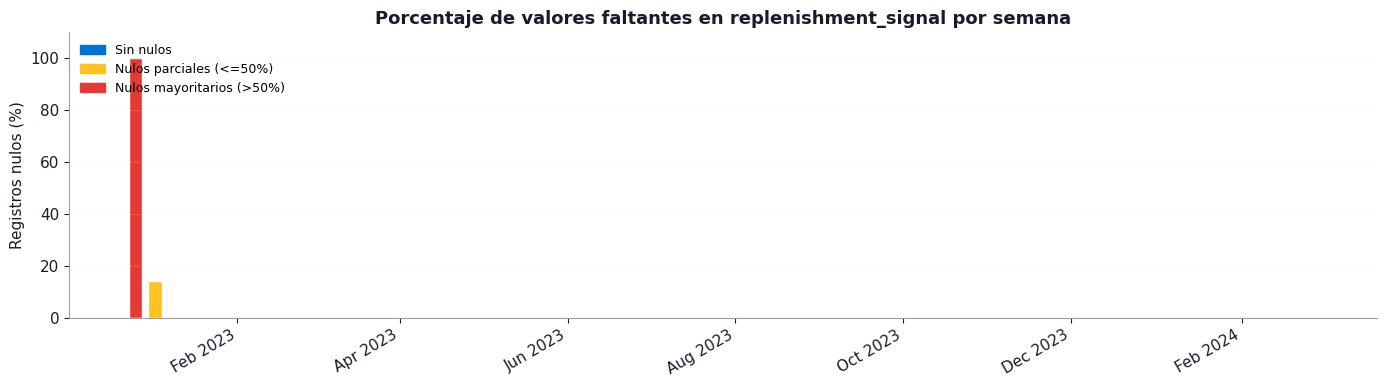

In [76]:
colors = [
    '#E53935' if v > 50 else WALMART_YELLOW if v > 0 else WALMART_BLUE
    for v in nulls_by_week['null_pct']
]

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(
    nulls_by_week['week'], nulls_by_week['null_pct'],
    width=5, color=colors, edgecolor='white'
)

ax.set_title('Porcentaje de valores faltantes en replenishment_signal por semana',
             fontsize=13, fontweight='bold', color=WALMART_DARK)
ax.set_ylabel('Registros nulos (%)')
ax.set_ylim(0, 110)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha='right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color=WALMART_BLUE,  label='Sin nulos'),
    Patch(color=WALMART_YELLOW, label='Nulos parciales (<=50%)'),
    Patch(color='#E53935',     label='Nulos mayoritarios (>50%)'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.25, color=WALMART_LGREY)
plt.tight_layout()
plt.show()


In [77]:
transactions[['replenishment_signal',
              'total_transactions']].corr()

,replenishment_signal,total_transactions
replenishment_signal,1.000000,0.850806
total_transactions,0.850806,1.000000


Aunque el diccionario menciona que los valores faltantes pueden concentrarse al final del periodo, en este conjunto de datos se observan únicamente al inicio de la serie. Esto sugiere que la señal podría requerir información histórica para su cálculo, por lo que durante los primeros días del periodo aún no existía suficiente contexto para generarla.

El dataset incluye una señal de reposición generada por un sistema interno. Aunque presenta una alta asociación con la demanda, esta variable parece formar parte del proceso operativo actual de reposición y no constituye un predictor independiente. Dado que el objetivo de este proyecto es anticipar la demanda para apoyar la planificación del inventario, la señal no será utilizada como entrada del modelo, sino considerada como un punto de referencia del proceso existente